In [17]:
pip install pytrends matplotlib seaborn plotly pandas

Note: you may need to restart the kernel to use updated packages.


# import library

In [18]:
import pandas as pd
from pytrends.request import TrendReq   # yaha from use hoga, Trendreq nahi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# PyTtrends setup aur Keyword Define karna

In [19]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=360)
keyword = 'cloud computing'

# data request karna

In [21]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')



# country-wise intrest nikalna

In [22]:
region_data = pytrends.interest_by_region()

region_data = region_data.sort_values(
    by=keyword,
    ascending=False
).head(15)

print(region_data)


               cloud computing
geoName                       
St. Helena                 100
Nepal                       89
India                       66
Ethiopia                    49
Ghana                       47
Kenya                       44
South Korea                 43
Sri Lanka                   41
Nigeria                     36
Singapore                   33
Pakistan                    32
United States               29
Tunisia                     26
South Africa                25
Malaysia                    21


# Complete working example (with keyword defined properly):

C:\Users\Devendra kushwah\AppData\Local\Temp\ipykernel_20992\3419990977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


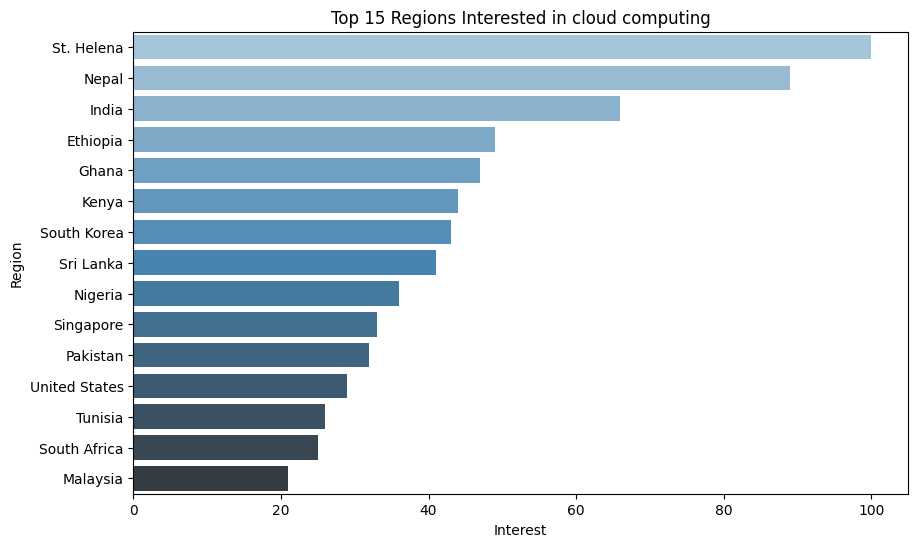

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=region_data[keyword],
    y=region_data.index,
    palette='Blues_d'   # correct palette
)

plt.title(f"Top 15 Regions Interested in {keyword}")
plt.xlabel("Interest")
plt.ylabel("Region")

plt.show()




# world map

C:\Users\Devendra kushwah\AppData\Local\Temp\ipykernel_20992\2480203371.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


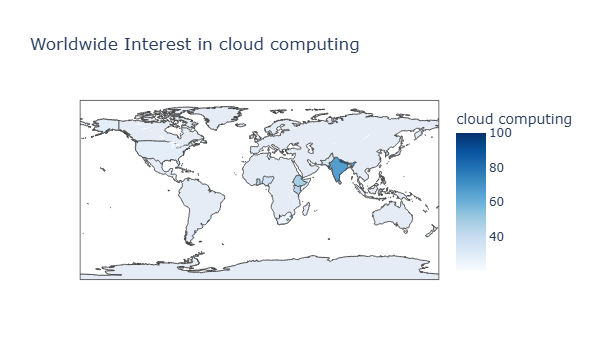

In [24]:
region_data = region_data.reset_index()

fig = px.choropleth(
    region_data,
    locations="geoName",        # country names
    locationmode="country names",
    color=keyword,
    title=f"Worldwide Interest in {keyword}",
    color_continuous_scale="Blues"
)

fig.show()


# time wise intrest

In [29]:
time_df = pytrends.interest_over_time()


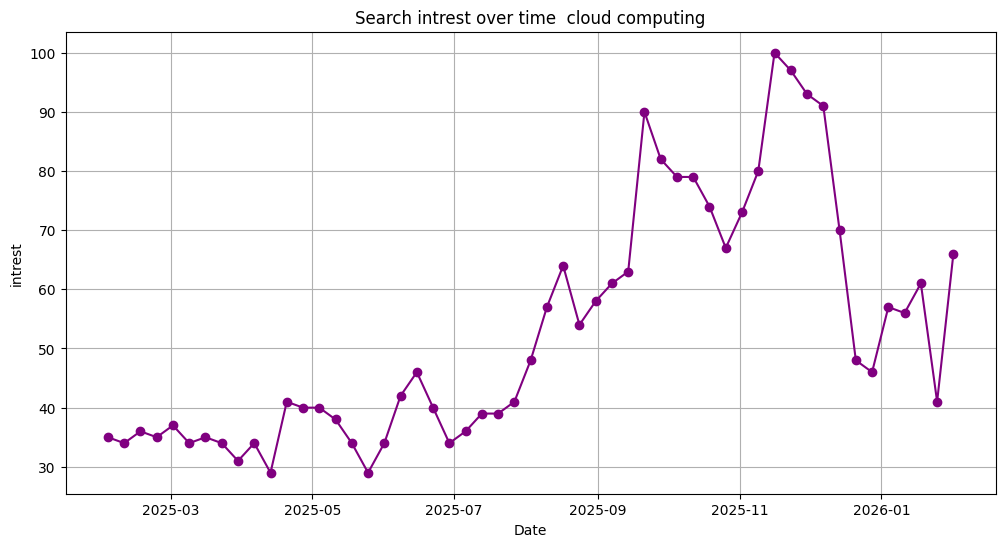

In [32]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index,time_df[keyword],marker = 'o',color='purple')
plt.title(f"Search intrest over time  {keyword}")
plt.xlabel("Date")
plt.ylabel("intrest")
plt.grid(True)

plt.show()



# multiple keyword compare

In [34]:
kw_list = ["cloud computing", "data science", "machine learning"]

pytrends.build_payload(
    kw_list,
    cat=0,
    timeframe='today 12-m',
    geo='',        # correct parameter
    gprop=''
)


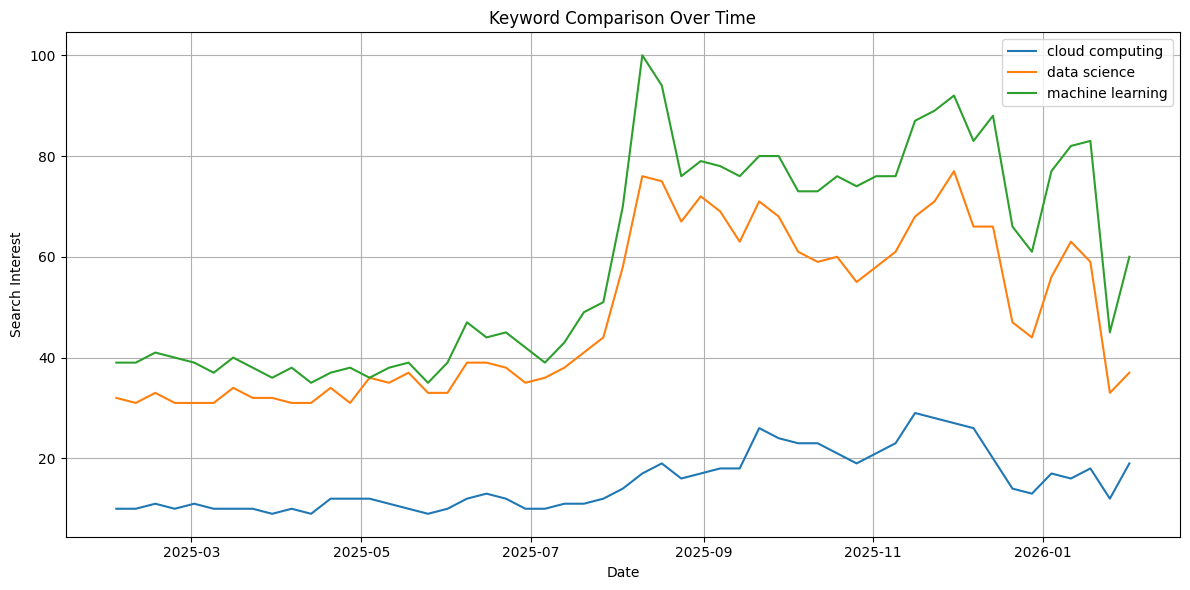

In [42]:
compare_df = pytrends.interest_over_time()

# Remove extra column


# Plot figure
plt.figure(figsize=(12,6))

for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("Keyword Comparison Over Time")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show figure
plt.show()
